In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [135]:
df1= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/팀플1/가설/부산시_행정구별_연도별_폐업수_2023_2025_분석용(이걸 종속변수로 사용하면 됩니다).csv")
df2= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/팀플1/가설/행정구별 소비매출 월별 월평균_전처리.csv")

In [136]:
print(df1.columns)
print(df2.columns)

Index(['연도', '행정구', '폐업수'], dtype='object')
Index(['연월', '행정구', '평균이용금액', '평균이용건수', '건당평균이용금액', '30일기준이용금액'], dtype='object')


In [137]:
# 연월(202301) -> 연도(2023)
df2["연도"] = df2["연월"].astype(str).str[:4].astype(int)

# 연도 + 행정구 기준으로 평균
df2_year = (
    df2.groupby(["연도", "행정구"], as_index=False)
       .agg({
           "평균이용금액": "mean",
           "평균이용건수": "mean",
           "건당평균이용금액": "mean",
           "30일기준이용금액": "mean"
       })
)

In [138]:
df = pd.merge(
    df1,
    df2_year,
    on=["연도", "행정구"],
    how="inner"
)

display(df.head())
print(df.shape)

,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074.408021,5826.000000,4.583333,152.000000
1,2025,금정구,3365,12632.518750,4046.750000,3.000000,102.583333
2,2025,기장군,3200,48451.741833,10492.500000,4.333333,145.416667
3,2025,남구,3676,12696.571029,4325.916667,3.000000,96.916667
4,2025,동구,2277,9586.522569,3159.583333,2.083333,83.333333


(48, 7)


In [139]:
print(df1["연도"].unique())

[2025 2024 2023]


In [140]:
# 연월 → 연도 추출
df2["연도"] = df2["연월"].astype(str).str[:4].astype(int)

# 연도별 평균 계산
df2_year = (
    df2.groupby(["연도", "행정구"], as_index=False)
       .agg({
           "평균이용금액": "mean",
           "평균이용건수": "mean",
           "건당평균이용금액": "mean",
           "30일기준이용금액": "mean"
       })
)

In [141]:
df = pd.merge(
    df1,
    df2_year,
    on=["연도", "행정구"],
    how="inner"
)

print(df.shape)
display(df.head())

(48, 7)


,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074.408021,5826.000000,4.583333,152.000000
1,2025,금정구,3365,12632.518750,4046.750000,3.000000,102.583333
2,2025,기장군,3200,48451.741833,10492.500000,4.333333,145.416667
3,2025,남구,3676,12696.571029,4325.916667,3.000000,96.916667
4,2025,동구,2277,9586.522569,3159.583333,2.083333,83.333333


In [142]:
df = pd.merge(
    df1,
    df2_year,
    on=["연도", "행정구"],
    how="inner"
)

print(df.shape)
display(df.head())

(48, 7)


,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074.408021,5826.000000,4.583333,152.000000
1,2025,금정구,3365,12632.518750,4046.750000,3.000000,102.583333
2,2025,기장군,3200,48451.741833,10492.500000,4.333333,145.416667
3,2025,남구,3676,12696.571029,4325.916667,3.000000,96.916667
4,2025,동구,2277,9586.522569,3159.583333,2.083333,83.333333


In [143]:
df

,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074.408021,5826.000000,4.583333,152.000000
1,2025,금정구,3365,12632.518750,4046.750000,3.000000,102.583333
2,2025,기장군,3200,48451.741833,10492.500000,4.333333,145.416667
3,2025,남구,3676,12696.571029,4325.916667,3.000000,96.916667
4,2025,동구,2277,9586.522569,3159.583333,2.083333,83.333333
5,2025,동래구,4090,23652.714744,6323.416667,3.000000,106.416667
6,2025,부산진구,6911,24702.423333,7181.250000,3.000000,96.750000
7,2025,북구,3275,21639.502756,6320.500000,2.250000,87.500000
8,2025,사상구,3533,17629.153472,5394.666667,2.833333,92.583333
9,2025,사하구,3797,14445.011042,4752.583333,2.416667,89.833333


In [144]:
# 소수점 제거(반올림 후 정수형으로 변환)
cols = ["평균이용금액", "평균이용건수", "건당평균이용금액", "30일기준이용금액"]

df[cols] = df[cols].round().astype(int)

display(df.head())

,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074,5826,5,152
1,2025,금정구,3365,12633,4047,3,103
2,2025,기장군,3200,48452,10492,4,145
3,2025,남구,3676,12697,4326,3,97
4,2025,동구,2277,9587,3160,2,83


In [145]:
df

,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074,5826,5,152
1,2025,금정구,3365,12633,4047,3,103
2,2025,기장군,3200,48452,10492,4,145
3,2025,남구,3676,12697,4326,3,97
4,2025,동구,2277,9587,3160,2,83
5,2025,동래구,4090,23653,6323,3,106
6,2025,부산진구,6911,24702,7181,3,97
7,2025,북구,3275,21640,6320,2,88
8,2025,사상구,3533,17629,5395,3,93
9,2025,사하구,3797,14445,4753,2,90


In [146]:
df_2025 = df[df["연도"] == 2025].copy()

지역별_매출 = (
    df_2025[
        ["행정구", "평균이용금액"]
    ]
    .sort_values("평균이용금액", ascending=False)
)

display(지역별_매출)

,행정구,평균이용금액
2,기장군,48452
15,해운대구,27273
0,강서구,27074
6,부산진구,24702
5,동래구,23653
7,북구,21640
11,수영구,19132
12,연제구,17685
8,사상구,17629
9,사하구,14445


In [147]:
지역별_변화 = (
    df.groupby(["행정구", "연도"])["평균이용금액"]
      .mean()
      .unstack()
)

지역별_변화

연도,2023,2024,2025
행정구,,,
강서구,30938.0,32574.0,27074.0
금정구,12172.0,12511.0,12633.0
기장군,46108.0,46597.0,48452.0
남구,11902.0,12160.0,12697.0
동구,8795.0,8965.0,9587.0
동래구,20884.0,22333.0,23653.0
부산진구,22907.0,23225.0,24702.0
북구,20040.0,20351.0,21640.0
사상구,17323.0,17419.0,17629.0


In [148]:
cols = [
    "평균이용금액",
    "평균이용건수",
    "건당평균이용금액",
    "30일기준이용금액"
]

df[cols] = df[cols].round().astype(int)

display(df.head())

,연도,행정구,폐업수,평균이용금액,평균이용건수,건당평균이용금액,30일기준이용금액
0,2025,강서구,3850,27074,5826,5,152
1,2025,금정구,3365,12633,4047,3,103
2,2025,기장군,3200,48452,10492,4,145
3,2025,남구,3676,12697,4326,3,97
4,2025,동구,2277,9587,3160,2,83


In [149]:
df_2025 = df[df["연도"] == 2025].copy()

In [150]:
df2 = df2.rename(columns={
    "평균이용금액": "평균이용금액(만원)",
    "건당평균이용금액": "건당평균이용금액(만원)",
    "30일기준이용금액": "30일기준이용금액(만원)"
})

print(df2.columns.tolist())

['연월', '행정구', '평균이용금액(만원)', '평균이용건수', '건당평균이용금액(만원)', '30일기준이용금액(만원)', '연도']


In [151]:
# 한글 폰트 설치
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕 폰트 경로
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 폰트 등록
fm.fontManager.addfont(font_path)

# 한글 폰트 적용
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 폰트 캐시 삭제
mpl.font_manager._load_fontmanager(try_read_cache=False)

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


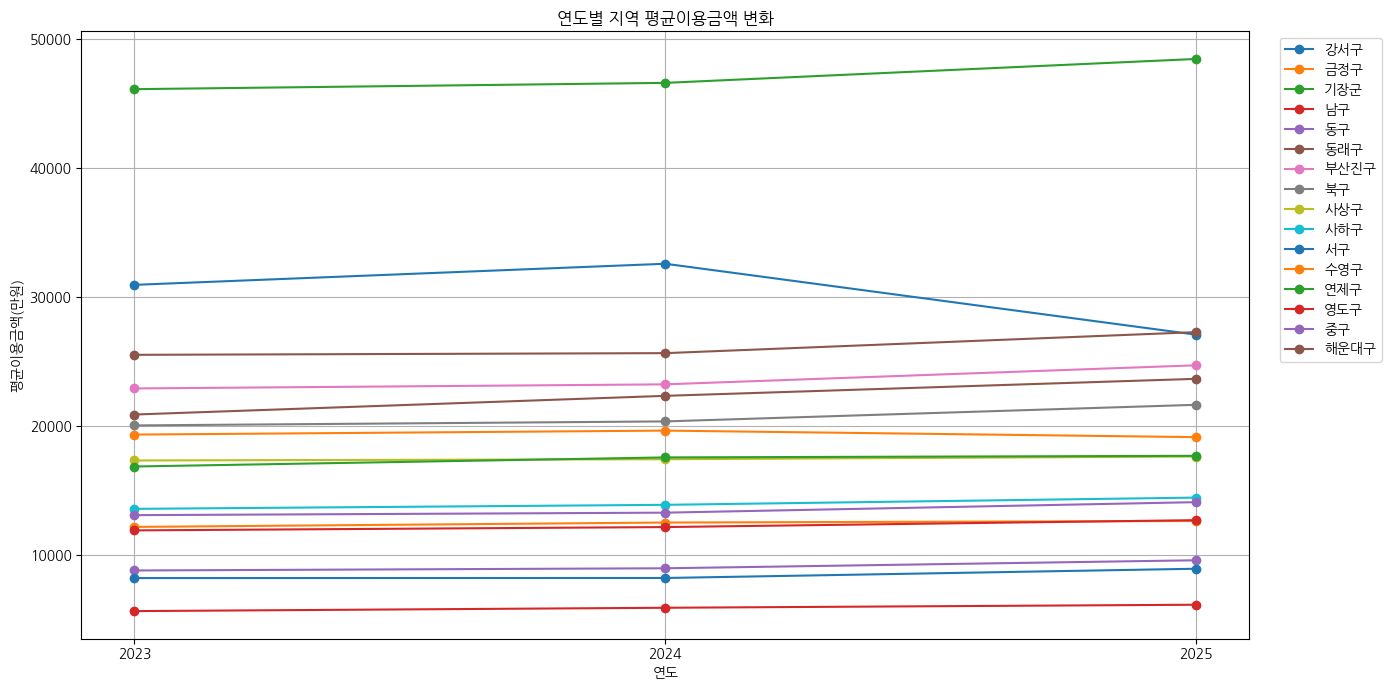

In [152]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 연도별·지역별 평균이용금액
지역별_연도 = (
    df2.groupby(["연도", "행정구"])["평균이용금액(만원)"]
    .mean()
    .reset_index()
)

# 그래프
plt.figure(figsize=(14, 7))

for 지역 in 지역별_연도["행정구"].unique():
    data = 지역별_연도[
        지역별_연도["행정구"] == 지역
    ]

    plt.plot(
        data["연도"],
        data["평균이용금액(만원)"],   # ← 여기 수정
        marker="o",
        label=지역
    )

plt.title("연도별 지역 평균이용금액 변화")
plt.xlabel("연도")
plt.ylabel("평균이용금액(만원)")
plt.xticks([2023, 2024, 2025])

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid()
plt.tight_layout()
plt.show()

In [153]:
print(df.columns.tolist())
print(df2.columns.tolist())

['연도', '행정구', '폐업수', '평균이용금액', '평균이용건수', '건당평균이용금액', '30일기준이용금액']
['연월', '행정구', '평균이용금액(만원)', '평균이용건수', '건당평균이용금액(만원)', '30일기준이용금액(만원)', '연도']


In [154]:
import os

save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"

os.makedirs(save_path, exist_ok=True)

print(save_path)
print("폴더 확인:", os.path.exists(save_path))

/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프
폴더 확인: True


In [162]:
import plotly.express as px
import os

# 저장 경로
save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"
os.makedirs(save_path, exist_ok=True)

# 연도는 문자열로 변환(드롭다운 표시용)
df_plot = df2.copy()
df_plot["연도"] = df_plot["연도"].astype(str)

# 인터랙티브 막대그래프
fig = px.bar(
    df_plot,
    x="행정구",
    y="평균이용금액(만원)",
    color="행정구",
    animation_frame="연도",
    title="연도별 행정구 평균이용금액",
    labels={
        "행정구": "행정구",
        "평균이용금액(만원)": "평균이용금액(만원)"
    }
)

# 그래프 크기
fig.update_layout(
    width=1100,
    height=600,
    xaxis_title="행정구",
    yaxis_title="평균이용금액(만원)",
    title_x=0.5
)

# HTML 저장
html_file = os.path.join(save_path, "지역별_평균이용금액.html")

fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True
)

print("저장 완료!")
print(html_file)

# Colab에서도 확인
fig.show()

저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/지역별_평균이용금액.html


In [156]:
%whos DatarFrame

No variables match your requested type.


In [168]:
import pandas as pd

df_plot = pd.merge(
    df2,
    df,
    on=["연도", "행정구"],
    how="inner"
)

print(df_plot.columns)
print(df_plot.head())

Index(['연월', '행정구', '평균이용금액(만원)', '평균이용건수_x', '건당평균이용금액(만원)', '30일기준이용금액(만원)',
       '연도', '폐업수', '평균이용금액', '평균이용건수_y', '건당평균이용금액', '30일기준이용금액'],
      dtype='object')
       연월  행정구    평균이용금액(만원)  평균이용건수_x  건당평균이용금액(만원)  30일기준이용금액(만원)    연도  \
0  202301  강서구  29443.553750      5353             5            179  2023   
1  202301  금정구  11411.598125      3276             3            112  2023   
2  202301  기장군  45315.506000      9101             5            162  2023   
3  202301   남구  11622.229412      3295             3            114  2023   
4  202301   동구   8248.735000      2422             3            102  2023   

    폐업수  평균이용금액  평균이용건수_y  건당평균이용금액  30일기준이용금액  
0  3755   30938      5829         5        167  
1  3645   12172      3690         3        109  
2  3429   46108      9868         4        147  
3  4104   11902      3738         3        104  
4  2212    8795      2716         3         92  


In [169]:
df_graph = df_plot[
    ["연도", "행정구", "폐업수", "평균이용금액"]
].copy()

df_graph = df_graph.rename(columns={
    "평균이용금액": "평균이용금액(만원)"
})

df_graph["연도"] = df_graph["연도"].astype(str)

print(df_graph.head())

     연도  행정구   폐업수  평균이용금액(만원)
0  2023  강서구  3755       30938
1  2023  금정구  3645       12172
2  2023  기장군  3429       46108
3  2023   남구  4104       11902
4  2023   동구  2212        8795


In [176]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# 저장 경로
save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"
os.makedirs(save_path, exist_ok=True)

# -----------------------------------
# 1. 폐업수 + 지역별 금액 데이터 병합
# -----------------------------------
df_plot = pd.merge(
    df2,
    df,
    on=["연도", "행정구"],
    how="inner"
)

# -----------------------------------
# 2. 필요한 컬럼만 사용
# -----------------------------------
df_graph = df_plot[
    ["연도", "행정구", "폐업수", "평균이용금액"]
].copy()

df_graph = df_graph.rename(columns={
    "평균이용금액": "평균이용금액(만원)"
})

df_graph["연도"] = df_graph["연도"].astype(str)

# -----------------------------------
# 3. 중복 제거
# -----------------------------------
df_graph = (
    df_graph
    .groupby(["연도", "행정구"], as_index=False)
    .agg({
        "폐업수": "first",
        "평균이용금액(만원)": "mean"
    })
)

# -----------------------------------
# 4. 연도 목록
# -----------------------------------
years = sorted(df_graph["연도"].unique())

# -----------------------------------
# 5. 첫 번째 연도 데이터
# -----------------------------------
year = years[0]

data = df_graph[
    df_graph["연도"] == year
].copy()

# 지역 정렬
data = data.sort_values(
    "평균이용금액(만원)",
    ascending=False
)

# -----------------------------------
# 6. 전체 평균이용금액
# -----------------------------------
overall_mean = data["평균이용금액(만원)"].mean()

# -----------------------------------
# 7. 보조 Y축
# -----------------------------------
fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

# -----------------------------------
# 8. 지역별 폐업수 막대
# -----------------------------------

# 보기 좋은 파스텔 계열 색상
bar_colors = [
    "#A8DADC",
    "#BDE0FE",
    "#CDB4DB",
    "#FFC8DD",
    "#FFD6A5",
    "#CAFFBF",
    "#9BF6FF",
    "#D8E2DC",
    "#FDE2E4",
    "#E2ECE9",
    "#CFBAF0",
    "#A9DEF9",
    "#E4C1F9",
    "#F1C0E8",
    "#FFCFD2",
    "#CDEAC0"
]

# 지역별 색상 지정
color_map = {}

for i, region in enumerate(data["행정구"]):
    color_map[region] = bar_colors[i % len(bar_colors)]

fig.add_trace(
    go.Bar(
        x=data["행정구"],
        y=data["폐업수"],
        name="폐업수",

        marker=dict(
            color=[
                color_map[region]
                for region in data["행정구"]
            ],
            line=dict(
                width=0
            )
        ),

        text=data["폐업수"].apply(
            lambda x: f"{x:,.0f}"
        ),

        texttemplate="%{text}",
        textposition="outside",

        hovertemplate=(
            "<b>%{x}</b><br>"
            "폐업수: %{y:,.0f}<extra></extra>"
        )
    ),
    secondary_y=False
)

# -----------------------------------
# 9. 지역별 평균이용금액 선
# -----------------------------------

fig.add_trace(
    go.Scatter(
        x=data["행정구"],
        y=data["평균이용금액(만원)"],
        name="지역 평균이용금액",

        mode="lines+markers+text",

        line=dict(
            color="#5B4B8A",
            width=3
        ),

        marker=dict(
            size=8,
            color="#5B4B8A"
        ),

        text=data["평균이용금액(만원)"].apply(
            lambda x: f"{x:,.0f}"
        ),

        textposition="top center",

        hovertemplate=(
            "<b>%{x}</b><br>"
            "평균이용금액: %{y:,.0f}만원"
            "<extra></extra>"
        )
    ),
    secondary_y=True
)

# -----------------------------------
# 10. 전체 평균이용금액 선
# -----------------------------------

fig.add_trace(
    go.Scatter(
        x=data["행정구"],
        y=[overall_mean] * len(data),
        name="전체 평균이용금액",

        mode="lines",

        line=dict(
            color="#E76F51",
            width=3,
            dash="dash"
        ),

        hovertemplate=(
            "전체 평균이용금액: "
            "%{y:,.0f}만원"
            "<extra></extra>"
        )
    ),
    secondary_y=True
)

# -----------------------------------
# 11. 그래프 설정
# -----------------------------------

fig.update_layout(
    title=f"{year}년 지역별 폐업수와 평균이용금액",
    width=1200,
    height=700,

    title_x=0.5,

    hovermode="x unified",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    plot_bgcolor="white"
)

# 왼쪽 Y축 - 폐업수
fig.update_yaxes(
    title_text="폐업수",
    secondary_y=False,
    tickformat=",",
    showgrid=True,
    gridcolor="#EAEAEA"
)

# 오른쪽 Y축 - 평균이용금액
fig.update_yaxes(
    title_text="평균이용금액 (만원)",
    secondary_y=True,
    tickformat=","
)

# X축
fig.update_xaxes(
    title_text="행정구",
    showgrid=False
)

# -----------------------------------
# 12. HTML 저장
# -----------------------------------

html_file = os.path.join(
    save_path,
    "지역별_폐업수_평균이용금액.html"
)

fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True
)

print("저장 완료!")
print(html_file)

fig.show()

저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/지역별_폐업수_평균이용금액.html


In [177]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# =========================================================
# 저장 경로
# =========================================================

save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"

png_path = os.path.join(save_path, "연도별")
html_path = os.path.join(save_path, "HTML")

os.makedirs(png_path, exist_ok=True)
os.makedirs(html_path, exist_ok=True)


# =========================================================
# 1. 폐업수 + 지역별 이용금액 병합
# =========================================================

df_plot = pd.merge(
    df2,
    df,
    on=["연도", "행정구"],
    how="inner"
)


# =========================================================
# 2. 그래프에 필요한 컬럼만 사용
# =========================================================

df_graph = df_plot[
    ["연도", "행정구", "폐업수", "평균이용금액"]
].copy()

df_graph = df_graph.rename(columns={
    "평균이용금액": "평균이용금액(만원)"
})


# =========================================================
# 3. 연도 + 행정구 기준으로 정리
# =========================================================

df_graph = (
    df_graph
    .groupby(["연도", "행정구"], as_index=False)
    .agg({
        "폐업수": "first",
        "평균이용금액(만원)": "mean"
    })
)

df_graph["연도"] = df_graph["연도"].astype(str)

years = sorted(df_graph["연도"].unique())


# =========================================================
# 4. 색상
# =========================================================

bar_colors = [
    "#A8DADC",
    "#BDE0FE",
    "#CDB4DB",
    "#FFC8DD",
    "#FFD6A5",
    "#CAFFBF",
    "#9BF6FF",
    "#D8E2DC",
    "#FDE2E4",
    "#E2ECE9",
    "#CFBAF0",
    "#A9DEF9",
    "#E4C1F9",
    "#F1C0E8",
    "#FFCFD2",
    "#CDEAC0"
]

line_color = "#5B4B8A"
overall_color = "#E76F51"


# =========================================================
# 5. 그래프 생성 함수
# =========================================================

def make_graph(data, year):

    data = data.copy()

    # 평균이용금액 높은 지역부터 정렬
    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    # 지역별 색상
    region_colors = [
        bar_colors[i % len(bar_colors)]
        for i in range(len(data))
    ]

    # 전체 평균
    overall_mean = data["평균이용금액(만원)"].mean()

    # 보조 Y축
    fig = make_subplots(
        specs=[[{"secondary_y": True}]]
    )

    # -----------------------------------------------------
    # 폐업수 막대
    # -----------------------------------------------------

    fig.add_trace(
        go.Bar(
            x=data["행정구"],
            y=data["폐업수"],
            name="폐업수",

            marker=dict(
                color=region_colors,
                line=dict(width=0)
            ),

            text=data["폐업수"].apply(
                lambda x: f"{x:,.0f}"
            ),

            texttemplate="%{text}",
            textposition="outside",

            hovertemplate=(
                "<b>%{x}</b><br>"
                "폐업수: %{y:,.0f}"
                "<extra></extra>"
            )
        ),
        secondary_y=False
    )

    # -----------------------------------------------------
    # 지역별 평균이용금액
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=data["행정구"],
            y=data["평균이용금액(만원)"],
            name="지역 평균이용금액",

            mode="lines+markers+text",

            line=dict(
                color=line_color,
                width=3
            ),

            marker=dict(
                size=8,
                color=line_color
            ),

            text=data["평균이용금액(만원)"].apply(
                lambda x: f"{x:,.0f}"
            ),

            textposition="top center",

            hovertemplate=(
                "<b>%{x}</b><br>"
                "평균이용금액: %{y:,.0f}만원"
                "<extra></extra>"
            )
        ),
        secondary_y=True
    )

    # -----------------------------------------------------
    # 전체 평균이용금액
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=data["행정구"],
            y=[overall_mean] * len(data),
            name="전체 평균이용금액",

            mode="lines",

            line=dict(
                color=overall_color,
                width=3,
                dash="dash"
            ),

            hovertemplate=(
                "전체 평균이용금액: "
                "%{y:,.0f}만원"
                "<extra></extra>"
            )
        ),
        secondary_y=True
    )

    # -----------------------------------------------------
    # 레이아웃
    # -----------------------------------------------------

    fig.update_layout(
        title=f"{year}년 지역별 폐업수와 평균이용금액",

        width=1200,
        height=700,

        title_x=0.5,

        hovermode="x unified",

        plot_bgcolor="white",

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        ),

        margin=dict(
            l=70,
            r=70,
            t=100,
            b=80
        )
    )

    # 폐업수 Y축
    fig.update_yaxes(
        title_text="폐업수",
        secondary_y=False,
        tickformat=",",
        showgrid=True,
        gridcolor="#EAEAEA"
    )

    # 평균이용금액 Y축
    fig.update_yaxes(
        title_text="평균이용금액 (만원)",
        secondary_y=True,
        tickformat=","
    )

    # X축
    fig.update_xaxes(
        title_text="행정구",
        showgrid=False
    )

    return fig

In [179]:
# =========================================================
# HTML용 인터랙티브 그래프
# =========================================================

initial_year = years[0]

initial_data = df_graph[
    df_graph["연도"] == initial_year
].copy()

fig = make_graph(
    initial_data,
    initial_year
)


# =========================================================
# 각 연도별 Frame 생성
# =========================================================

frames = []

for year in years:

    data = df_graph[
        df_graph["연도"] == year
    ].copy()

    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    overall_mean = data[
        "평균이용금액(만원)"
    ].mean()

    region_colors = [
        bar_colors[i % len(bar_colors)]
        for i in range(len(data))
    ]

    frames.append(
        go.Frame(
            name=year,

            data=[
                go.Bar(
                    x=data["행정구"],
                    y=data["폐업수"],

                    marker=dict(
                        color=region_colors,
                        line=dict(width=0)
                    ),

                    text=data["폐업수"].apply(
                        lambda x: f"{x:,.0f}"
                    ),

                    texttemplate="%{text}",
                    textposition="outside",

                    hovertemplate=(
                        "<b>%{x}</b><br>"
                        "폐업수: %{y:,.0f}"
                        "<extra></extra>"
                    )
                ),

                go.Scatter(
                    x=data["행정구"],
                    y=data["평균이용금액(만원)"],

                    mode="lines+markers+text",

                    line=dict(
                        color=line_color,
                        width=3
                    ),

                    marker=dict(
                        size=8,
                        color=line_color
                    ),

                    text=data["평균이용금액(만원)"].apply(
                        lambda x: f"{x:,.0f}"
                    ),

                    textposition="top center",

                    hovertemplate=(
                        "<b>%{x}</b><br>"
                        "평균이용금액: %{y:,.0f}만원"
                        "<extra></extra>"
                    )
                ),

                go.Scatter(
                    x=data["행정구"],
                    y=[overall_mean] * len(data),

                    mode="lines",

                    line=dict(
                        color=overall_color,
                        width=3,
                        dash="dash"
                    ),

                    hovertemplate=(
                        "전체 평균이용금액: "
                        "%{y:,.0f}만원"
                        "<extra></extra>"
                    )
                )
            ],

            layout=go.Layout(
                title=f"{year}년 지역별 폐업수와 평균이용금액"
            )
        )
    )


fig.frames = frames


# =========================================================
# 연도 선택 버튼
# =========================================================

buttons = []

for year in years:

    buttons.append(
        dict(
            label=year,
            method="animate",

            args=[
                [year],

                dict(
                    mode="immediate",

                    frame=dict(
                        duration=500,
                        redraw=True
                    ),

                    transition=dict(
                        duration=300
                    )
                )
            ]
        )
    )


fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",

            buttons=buttons,

            direction="down",

            x=0.5,
            y=1.15,

            xanchor="center",
            yanchor="top",

            showactive=True
        )
    ]
)


# =========================================================
# HTML 저장
# =========================================================

html_file = os.path.join(
    html_path,
    "지역별_폐업수_평균이용금액_연도선택.html"
)

fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True
)

print("HTML 저장 완료!")
print(html_file)

fig.show()

HTML 저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/HTML/지역별_폐업수_평균이용금액_연도선택.html


In [185]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import os

# =========================================================
# 1. 저장 경로
# =========================================================

save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"
os.makedirs(save_path, exist_ok=True)


# =========================================================
# 2. 폐업수 + 평균이용금액 데이터 준비
# =========================================================

df_plot = pd.merge(
    df2,
    df,
    on=["연도", "행정구"],
    how="inner"
)

# 필요한 컬럼만 사용
df_model = df_plot[
    ["연도", "행정구", "폐업수", "평균이용금액"]
].copy()

# 컬럼명 통일
df_model = df_model.rename(columns={
    "평균이용금액": "평균이용금액(만원)"
})

# 숫자형 변환
df_model["연도"] = pd.to_numeric(
    df_model["연도"],
    errors="coerce"
)

df_model["폐업수"] = pd.to_numeric(
    df_model["폐업수"],
    errors="coerce"
)

df_model["평균이용금액(만원)"] = pd.to_numeric(
    df_model["평균이용금액(만원)"],
    errors="coerce"
)

# =========================================================
# 3. 연도 + 행정구 기준으로 정리
# =========================================================

df_model = (
    df_model
    .groupby(["연도", "행정구"], as_index=False)
    .agg({
        "폐업수": "first",
        "평균이용금액(만원)": "mean"
    })
)

# 실제 데이터만 사용
df_actual = df_model[
    df_model["연도"].isin([2023, 2024, 2025])
].copy()

df_actual["구분"] = "실제"


# =========================================================
# 4. 지역별 2026 / 2027 선형회귀 예측
# =========================================================

prediction_list = []

regions = df_actual["행정구"].unique()

for region in regions:

    region_data = df_actual[
        df_actual["행정구"] == region
    ].sort_values("연도")

    # ---------------------------------------------
    # 데이터가 3년 모두 있는지 확인
    # ---------------------------------------------

    if len(region_data) < 3:
        print(f"{region}: 데이터 부족 → 예측 제외")
        continue

    X = region_data[["연도"]]

    # =============================================
    # 폐업수 선형회귀
    # =============================================

    y_close = region_data["폐업수"]

    model_close = LinearRegression()
    model_close.fit(X, y_close)

    # =============================================
    # 평균이용금액 선형회귀
    # =============================================

    y_amount = region_data["평균이용금액(만원)"]

    model_amount = LinearRegression()
    model_amount.fit(X, y_amount)

    # =============================================
    # 2026 / 2027 예측
    # =============================================

    future_years = np.array([
        [2026],
        [2027]
    ])

    predicted_close = model_close.predict(
        future_years
    )

    predicted_amount = model_amount.predict(
        future_years
    )

    # =============================================
    # 예측값 정리
    # =============================================

    for i, year in enumerate([2026, 2027]):

        prediction_list.append({
            "연도": year,
            "행정구": region,

            "폐업수": max(
                0,
                round(predicted_close[i])
            ),

            "평균이용금액(만원)": max(
                0,
                round(predicted_amount[i])
            ),

            "구분": "예측"
        })


# =========================================================
# 5. 예측 데이터프레임
# =========================================================

df_prediction = pd.DataFrame(
    prediction_list
)

print("2026~2027 예측 데이터")
display(df_prediction)


# =========================================================
# 6. 실제 + 예측 데이터 통합
# =========================================================

df_actual_final = df_actual[
    ["연도", "행정구", "폐업수",
     "평균이용금액(만원)", "구분"]
].copy()

df_all = pd.concat(
    [
        df_actual_final,
        df_prediction
    ],
    ignore_index=True
)

df_all = df_all.sort_values(
    ["연도", "행정구"]
).reset_index(drop=True)


# =========================================================
# 7. CSV 저장
# =========================================================

csv_file = os.path.join(
    save_path,
    "지역별_폐업수_평균이용금액_2023_2027_예측.csv"
)

df_all.to_csv(
    csv_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")
print(csv_file)


# =========================================================
# 8. 결과 확인
# =========================================================

display(df_all)

2026~2027 예측 데이터


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid featu

,연도,행정구,폐업수,평균이용금액(만원),구분
0,2026,강서구,4004,26331,예측
1,2027,강서구,4052,24399,예측
2,2026,금정구,3224,12900,예측
3,2027,금정구,3084,13130,예측
4,2026,기장군,3121,49396,예측
5,2027,기장군,3006,50568,예측
6,2026,남구,3484,13048,예측
7,2027,남구,3270,13446,예측
8,2026,동구,2270,9908,예측
9,2027,동구,2302,10304,예측


저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/지역별_폐업수_평균이용금액_2023_2027_예측.csv


,연도,행정구,폐업수,평균이용금액(만원),구분
0,2023,강서구,3755,30938.0,실제
1,2023,금정구,3645,12172.0,실제
2,2023,기장군,3429,46108.0,실제
3,2023,남구,4104,11902.0,실제
4,2023,동구,2212,8795.0,실제
...,...,...,...,...,...
75,2027,수영구,3180,19070.0,예측
76,2027,연제구,3672,18612.0,예측
77,2027,영도구,1419,6638.0,예측
78,2027,중구,1617,14996.0,예측


In [187]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# =========================================================
# 1. 저장 경로
# =========================================================

save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"
os.makedirs(save_path, exist_ok=True)


# =========================================================
# 2. 연도 목록
# =========================================================

years = sorted(df_all["연도"].unique())

print("그래프 연도:", years)


# =========================================================
# 3. 색상 설정
# =========================================================

bar_colors = [
    "#A8DADC",
    "#BDE0FE",
    "#CDB4DB",
    "#FFC8DD",
    "#FFD6A5",
    "#CAFFBF",
    "#9BF6FF",
    "#D8E2DC",
    "#FDE2E4",
    "#E2ECE9",
    "#CFBAF0",
    "#A9DEF9",
    "#E4C1F9",
    "#F1C0E8",
    "#FFCFD2",
    "#CDEAC0"
]

line_color = "#5B4B8A"
overall_color = "#E76F51"


# =========================================================
# 4. 그래프 생성 함수
# =========================================================

def create_year_graph(data, year):

    data = data.copy()

    # 평균이용금액 높은 순으로 정렬
    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    # 전체 평균
    overall_mean = data[
        "평균이용금액(만원)"
    ].mean()

    # 실제 / 예측 구분
    year_type = data["구분"].iloc[0]

    if year_type == "예측":
        title = f"{year}년 지역별 폐업수와 평균이용금액 (예측)"
    else:
        title = f"{year}년 지역별 폐업수와 평균이용금액 (실제)"

    # -----------------------------------------------------
    # 보조 Y축
    # -----------------------------------------------------

    fig = make_subplots(
        specs=[[{"secondary_y": True}]]
    )

    # -----------------------------------------------------
    # 폐업수 막대
    # -----------------------------------------------------

    fig.add_trace(
        go.Bar(
            x=data["행정구"],
            y=data["폐업수"],

            name="폐업수",

            marker=dict(
                color=[
                    bar_colors[i % len(bar_colors)]
                    for i in range(len(data))
                ],
                line=dict(width=0)
            ),

            text=data["폐업수"].apply(
                lambda x: f"{x:,.0f}"
            ),

            texttemplate="%{text}",
            textposition="outside",

            hovertemplate=(
                "<b>%{x}</b><br>"
                "폐업수: %{y:,.0f}"
                "<extra></extra>"
            )
        ),
        secondary_y=False
    )

    # -----------------------------------------------------
    # 지역별 평균이용금액
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=data["행정구"],
            y=data["평균이용금액(만원)"],

            name="지역 평균이용금액",

            mode="lines+markers+text",

            line=dict(
                color=line_color,
                width=3
            ),

            marker=dict(
                size=8,
                color=line_color
            ),

            text=data["평균이용금액(만원)"].apply(
                lambda x: f"{x:,.0f}"
            ),

            textposition="top center",

            hovertemplate=(
                "<b>%{x}</b><br>"
                "평균이용금액: %{y:,.0f}만원"
                "<extra></extra>"
            )
        ),
        secondary_y=True
    )

    # -----------------------------------------------------
    # 전체 평균이용금액
    # -----------------------------------------------------

    fig.add_trace(
        go.Scatter(
            x=data["행정구"],
            y=[overall_mean] * len(data),

            name="전체 평균이용금액",

            mode="lines",

            line=dict(
                color=overall_color,
                width=3,
                dash="dash"
            ),

            hovertemplate=(
                "전체 평균이용금액: "
                "%{y:,.0f}만원"
                "<extra></extra>"
            )
        ),
        secondary_y=True
    )

    # -----------------------------------------------------
    # 예측 여부 표시
    # -----------------------------------------------------

    if year_type == "예측":
        annotation_text = "※ 선형회귀 기반 예측값"
    else:
        annotation_text = "※ 실제 데이터"

    # -----------------------------------------------------
    # 레이아웃
    # -----------------------------------------------------

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5
        ),

        width=1200,
        height=700,

        hovermode="x unified",

        plot_bgcolor="white",

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        ),

        margin=dict(
            l=70,
            r=70,
            t=110,
            b=80
        ),

        annotations=[
            dict(
                text=annotation_text,
                x=1,
                y=-0.15,
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(
                    size=12
                )
            )
        ]
    )

    # 왼쪽 Y축
    fig.update_yaxes(
        title_text="폐업수",
        secondary_y=False,
        tickformat=",",
        showgrid=True,
        gridcolor="#EAEAEA"
    )

    # 오른쪽 Y축
    fig.update_yaxes(
        title_text="평균이용금액 (만원)",
        secondary_y=True,
        tickformat=","
    )

    # X축
    fig.update_xaxes(
        title_text="행정구",
        showgrid=False
    )

    return fig


# =========================================================
# 5. 첫 번째 연도 그래프
# =========================================================

first_year = years[0]

first_data = df_all[
    df_all["연도"] == first_year
].copy()

fig = create_year_graph(
    first_data,
    first_year
)


# =========================================================
# 6. 연도별 Frame 생성
# =========================================================

frames = []

for year in years:

    data = df_all[
        df_all["연도"] == year
    ].copy()

    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    overall_mean = data[
        "평균이용금액(만원)"
    ].mean()

    year_type = data["구분"].iloc[0]

    if year_type == "예측":
        title = f"{year}년 지역별 폐업수와 평균이용금액 (예측)"
    else:
        title = f"{year}년 지역별 폐업수와 평균이용금액 (실제)"

    frame = go.Frame(
        name=str(year),

        data=[
            # -----------------------------------------
            # 폐업수
            # -----------------------------------------
            go.Bar(
                x=data["행정구"],
                y=data["폐업수"],

                marker=dict(
                    color=[
                        bar_colors[i % len(bar_colors)]
                        for i in range(len(data))
                    ]
                ),

                text=data["폐업수"].apply(
                    lambda x: f"{x:,.0f}"
                ),

                texttemplate="%{text}",
                textposition="outside",

                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "폐업수: %{y:,.0f}"
                    "<extra></extra>"
                )
            ),

            # -----------------------------------------
            # 지역별 평균이용금액
            # -----------------------------------------
            go.Scatter(
                x=data["행정구"],
                y=data["평균이용금액(만원)"],

                mode="lines+markers+text",

                line=dict(
                    color=line_color,
                    width=3
                ),

                marker=dict(
                    size=8,
                    color=line_color
                ),

                text=data["평균이용금액(만원)"].apply(
                    lambda x: f"{x:,.0f}"
                ),

                textposition="top center",

                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "평균이용금액: %{y:,.0f}만원"
                    "<extra></extra>"
                )
            ),

            # -----------------------------------------
            # 전체 평균이용금액
            # -----------------------------------------
            go.Scatter(
                x=data["행정구"],
                y=[overall_mean] * len(data),

                mode="lines",

                line=dict(
                    color=overall_color,
                    width=3,
                    dash="dash"
                ),

                hovertemplate=(
                    "전체 평균이용금액: "
                    "%{y:,.0f}만원"
                    "<extra></extra>"
                )
            )
        ],

        layout=go.Layout(
            title=dict(
                text=title,
                x=0.5
            )
        )
    )

    frames.append(frame)


fig.frames = frames


# =========================================================
# 7. 드롭다운 버튼
# =========================================================

buttons = []

for year in years:

    year_type = df_all[
        df_all["연도"] == year
    ]["구분"].iloc[0]

    if year_type == "예측":
        label = f"{year}년 (예측)"
    else:
        label = f"{year}년 (실제)"

    buttons.append(
        dict(
            label=label,

            method="animate",

            args=[
                [str(year)],

                dict(
                    mode="immediate",

                    frame=dict(
                        duration=500,
                        redraw=True
                    ),

                    transition=dict(
                        duration=300
                    )
                )
            ]
        )
    )


# =========================================================
# 8. 드롭다운 추가
# =========================================================

fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            buttons=buttons,

            direction="down",

            # 제목 아래쪽에 배치
            x=0.5,
            y=1.08,

            xanchor="center",
            yanchor="top",

            showactive=True
        )
    ],

    # 제목과 버튼을 위한 위쪽 공간 확보
    margin=dict(
        l=70,
        r=70,
        t=150,
        b=80
    )
)


# =========================================================
# 9. HTML 저장
# =========================================================

html_file = os.path.join(
    save_path,
    "지역별_폐업수_평균이용금액_2023_2027_예측.html"
)

fig.write_html(
    html_file,
    include_plotlyjs=True,
    full_html=True
)

print("======================================")
print("HTML 저장 완료!")
print("======================================")
print(html_file)

# Colab에서 바로 확인
fig.show()

그래프 연도: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027)]
HTML 저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/지역별_폐업수_평균이용금액_2023_2027_예측.html


In [188]:
# 2023년과 2027년 비교
df_compare = df_all[
    df_all["연도"].isin([2023, 2027])
].pivot(
    index="행정구",
    columns="연도",
    values=["폐업수", "평균이용금액(만원)"]
)

# 컬럼명 정리
df_compare.columns = [
    f"{col}_{year}"
    for col, year in df_compare.columns
]

# 변화량 계산
df_compare["폐업수_변화"] = (
    df_compare["폐업수_2027"] -
    df_compare["폐업수_2023"]
)

df_compare["폐업수_변화율(%)"] = (
    (df_compare["폐업수_2027"] -
     df_compare["폐업수_2023"])
    / df_compare["폐업수_2023"]
    * 100
)

df_compare["평균이용금액_변화"] = (
    df_compare["평균이용금액(만원)_2027"] -
    df_compare["평균이용금액(만원)_2023"]
)

df_compare["평균이용금액_변화율(%)"] = (
    (df_compare["평균이용금액(만원)_2027"] -
     df_compare["평균이용금액(만원)_2023"])
    / df_compare["평균이용금액(만원)_2023"]
    * 100
)

# 폐업수 변화율 기준으로 정렬
result = df_compare.sort_values(
    "폐업수_변화율(%)",
    ascending=False
)

display(result.round(1))

,폐업수_2023,폐업수_2027,평균이용금액(만원)_2023,평균이용금액(만원)_2027,폐업수_변화,폐업수_변화율(%),평균이용금액_변화,평균이용금액_변화율(%)
행정구,,,,,,,,
강서구,3755.0,4052.0,30938.0,24399.0,297.0,7.9,-6539.0,-21.1
영도구,1360.0,1419.0,5644.0,6638.0,59.0,4.3,994.0,17.6
동구,2212.0,2302.0,8795.0,10304.0,90.0,4.1,1509.0,17.2
서구,1434.0,1480.0,8206.0,9535.0,46.0,3.2,1329.0,16.2
연제구,3616.0,3672.0,16855.0,18612.0,56.0,1.5,1757.0,10.4
부산진구,7057.0,6875.0,22907.0,26304.0,-182.0,-2.6,3397.0,14.8
동래구,4195.0,3987.0,20884.0,26444.0,-208.0,-5.0,5560.0,26.6
북구,3486.0,3072.0,20040.0,23077.0,-414.0,-11.9,3037.0,15.2
기장군,3429.0,3006.0,46108.0,50568.0,-423.0,-12.3,4460.0,9.7


In [195]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os


# =========================================================
# 1. 저장 경로
# =========================================================

save_path = "/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프"

os.makedirs(save_path, exist_ok=True)


# =========================================================
# 2. 데이터 준비
# =========================================================

df_all = df_all.copy()

df_all["연도"] = pd.to_numeric(
    df_all["연도"],
    errors="coerce"
)

df_all["폐업수"] = pd.to_numeric(
    df_all["폐업수"],
    errors="coerce"
)

df_all["평균이용금액(만원)"] = pd.to_numeric(
    df_all["평균이용금액(만원)"],
    errors="coerce"
)


# 기존 변화율 컬럼 제거
remove_cols = [
    "폐업수_변화율(%)",
    "평균이용금액_변화율(%)",
    "변동성순위"
]

df_all = df_all.drop(
    columns=[
        col for col in remove_cols
        if col in df_all.columns
    ]
)


# =========================================================
# 3. 2023 → 2027 변화율 계산
# =========================================================

change_data = df_all[
    df_all["연도"].isin([2023, 2027])
].pivot(
    index="행정구",
    columns="연도",
    values=[
        "폐업수",
        "평균이용금액(만원)"
    ]
)


change_data.columns = [
    f"{value}_{year}"
    for value, year in change_data.columns
]

change_data = change_data.reset_index()


# =========================================================
# 4. 폐업수 변화율
# =========================================================

change_data["폐업수_변화율(%)"] = (
    (
        change_data["폐업수_2027"]
        -
        change_data["폐업수_2023"]
    )
    /
    change_data["폐업수_2023"]
    * 100
)


# =========================================================
# 5. 평균이용금액 변화율
# =========================================================

change_data["평균이용금액_변화율(%)"] = (
    (
        change_data["평균이용금액(만원)_2027"]
        -
        change_data["평균이용금액(만원)_2023"]
    )
    /
    change_data["평균이용금액(만원)_2023"]
    * 100
)


# =========================================================
# 6. 변동성 순위
# =========================================================

change_data["변동성순위"] = (
    change_data["폐업수_변화율(%)"]
    .abs()
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# =========================================================
# 7. TOP 10 데이터
# =========================================================

ranking_data = (
    change_data
    .sort_values("변동성순위")
    .head(10)
    .copy()
)


# 확인용 출력
print("========================================")
print("2023 → 2027 변동성 TOP 10")
print("========================================")

display(
    ranking_data[
        [
            "변동성순위",
            "행정구",
            "폐업수_2023",
            "폐업수_2027",
            "폐업수_변화율(%)",
            "평균이용금액(만원)_2023",
            "평균이용금액(만원)_2027",
            "평균이용금액_변화율(%)"
        ]
    ].round(1)
)


# =========================================================
# 8. df_all에 변화율 추가
# =========================================================

df_all = df_all.merge(
    change_data[
        [
            "행정구",
            "폐업수_변화율(%)",
            "평균이용금액_변화율(%)",
            "변동성순위"
        ]
    ],
    on="행정구",
    how="left"
)


# =========================================================
# 9. 연도
# =========================================================

years = sorted(
    df_all["연도"].dropna().unique()
)

print()
print("연도:", years)


# =========================================================
# 10. 색상
# =========================================================

bar_colors = [
    "#A8DADC",
    "#BDE0FE",
    "#CDB4DB",
    "#FFC8DD",
    "#FFD6A5",
    "#CAFFBF",
    "#9BF6FF",
    "#D8E2DC",
    "#FDE2E4",
    "#E2ECE9",
    "#CFBAF0",
    "#A9DEF9",
    "#E4C1F9",
    "#F1C0E8",
    "#FFCFD2",
    "#CDEAC0"
]

line_color = "#5B4B8A"
overall_color = "#E76F51"


# =========================================================
# 11. TOP 10 순위표 HTML
# =========================================================

def create_ranking_text():

    text = (
        "<b style='font-size:16px;'>"
        "2023 → 2027<br>"
        "변동성 TOP 10"
        "</b>"
        "<br><br>"
    )

    for _, row in ranking_data.iterrows():

        rank = int(row["변동성순위"])
        region = row["행정구"]

        close_change = row[
            "폐업수_변화율(%)"
        ]

        amount_change = row[
            "평균이용금액_변화율(%)"
        ]

        text += (
            f"<b>{rank}위　{region}</b><br>"
            f"폐업수　"
            f"<b>{close_change:+.1f}%</b>"
            f"<br>"
            f"이용금액　"
            f"<b>{amount_change:+.1f}%</b>"
            f"<br><br>"
        )

    return text


ranking_text = create_ranking_text()


# =========================================================
# 12. 그래프 생성
# =========================================================

def create_graph(data, year):

    data = data.copy()

    # 평균이용금액 높은 순
    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    year_type = data["구분"].iloc[0]

    if year_type == "예측":

        title = (
            f"{year}년 지역별 폐업수와 "
            f"평균이용금액 (예측)"
        )

    else:

        title = (
            f"{year}년 지역별 폐업수와 "
            f"평균이용금액 (실제)"
        )


    # 전체 평균
    overall_mean = data[
        "평균이용금액(만원)"
    ].mean()


    # =====================================================
    # 그래프 생성
    # =====================================================

    fig = make_subplots(

        rows=1,
        cols=1,

        specs=[
            [
                {
                    "secondary_y": True
                }
            ]
        ]
    )


    # =====================================================
    # 1. 폐업수 막대
    # =====================================================

    fig.add_trace(

        go.Bar(

            x=data["행정구"],

            y=data["폐업수"],

            name="폐업수",

            marker=dict(

                color=[
                    bar_colors[
                        i % len(bar_colors)
                    ]

                    for i in range(len(data))
                ]
            ),

            text=[
                f"{x:,.0f}"

                for x in data["폐업수"]
            ],

            texttemplate="%{text}",

            textposition="outside",

            cliponaxis=False,

            hovertemplate=(

                "<b>%{x}</b><br>"

                "폐업수: %{y:,.0f}"

                "<extra></extra>"
            )
        ),

        secondary_y=False
    )


    # =====================================================
    # 2. 지역별 평균이용금액
    # =====================================================

    fig.add_trace(

        go.Scatter(

            x=data["행정구"],

            y=data[
                "평균이용금액(만원)"
            ],

            name="지역 평균이용금액",

            mode="lines+markers+text",

            line=dict(

                color=line_color,

                width=3
            ),

            marker=dict(

                size=8,

                color=line_color
            ),

            text=[
                f"{x:,.0f}"

                for x in data[
                    "평균이용금액(만원)"
                ]
            ],

            textposition="top center",

            hovertemplate=(

                "<b>%{x}</b><br>"

                "평균이용금액: "
                "%{y:,.0f}만원"

                "<extra></extra>"
            )
        ),

        secondary_y=True
    )


    # =====================================================
    # 3. 전체 평균이용금액
    # =====================================================

    fig.add_trace(

        go.Scatter(

            x=data["행정구"],

            y=[
                overall_mean
            ] * len(data),

            name="전체 평균이용금액",

            mode="lines",

            line=dict(

                color=overall_color,

                width=3,

                dash="dash"
            ),

            hovertemplate=(

                "전체 평균이용금액: "
                "%{y:,.0f}만원"

                "<extra></extra>"
            )
        ),

        secondary_y=True
    )


    # =====================================================
    # 4. 전체 레이아웃
    # =====================================================

    fig.update_layout(

        title=dict(

            text=title,

            x=0.38,

            xanchor="center"
        ),

        width=1750,

        height=820,

        hovermode="x unified",

        plot_bgcolor="white",

        legend=dict(

            orientation="h",

            yanchor="bottom",

            y=1.01,

            xanchor="center",

            x=0.38
        ),

        # 오른쪽 TOP10을 위한 공간
        margin=dict(

            l=70,

            r=500,

            t=190,

            b=100
        )
    )


    # =====================================================
    # 5. 폐업수 Y축
    # =====================================================

    fig.update_yaxes(

        title_text="폐업수",

        tickformat=",",

        showgrid=True,

        gridcolor="#EAEAEA",

        secondary_y=False
    )


    # =====================================================
    # 6. 평균이용금액 Y축
    # =====================================================

    fig.update_yaxes(

        title_text="평균이용금액 (만원)",

        tickformat=",",

        secondary_y=True
    )


    # =====================================================
    # 7. X축
    # =====================================================

    fig.update_xaxes(

        title_text="행정구",

        showgrid=False,

        tickangle=0,

        automargin=True
    )


    # =====================================================
    # 8. 오른쪽 TOP 10 패널
    # =====================================================

    fig.add_annotation(

        text=ranking_text,

        x=1.035,

        y=0.50,

        xref="paper",

        yref="paper",

        showarrow=False,

        align="left",

        font=dict(

            size=11
        ),

        bordercolor="#DDDDDD",

        borderwidth=1,

        borderpad=15,

        bgcolor="#FAFAFA"
    )


    return fig


# =========================================================
# 13. 첫 그래프
# =========================================================

first_year = years[0]

first_data = df_all[
    df_all["연도"] == first_year
].copy()

fig = create_graph(
    first_data,
    first_year
)


# =========================================================
# 14. Frame 생성
# =========================================================

frames = []

for year in years:

    data = df_all[
        df_all["연도"] == year
    ].copy()

    data = data.sort_values(
        "평균이용금액(만원)",
        ascending=False
    )

    overall_mean = data[
        "평균이용금액(만원)"
    ].mean()

    year_type = data[
        "구분"
    ].iloc[0]


    if year_type == "예측":

        title = (
            f"{year}년 지역별 폐업수와 "
            f"평균이용금액 (예측)"
        )

    else:

        title = (
            f"{year}년 지역별 폐업수와 "
            f"평균이용금액 (실제)"
        )


    frames.append(

        go.Frame(

            name=str(year),

            data=[

                # -----------------------------------------
                # 폐업수
                # -----------------------------------------

                go.Bar(

                    x=data["행정구"],

                    y=data["폐업수"],

                    marker=dict(

                        color=[
                            bar_colors[
                                i % len(bar_colors)
                            ]

                            for i in range(
                                len(data)
                            )
                        ]
                    ),

                    text=[
                        f"{x:,.0f}"

                        for x in data[
                            "폐업수"
                        ]
                    ],

                    texttemplate="%{text}",

                    textposition="outside",

                    cliponaxis=False,

                    hovertemplate=(

                        "<b>%{x}</b><br>"

                        "폐업수: %{y:,.0f}"

                        "<extra></extra>"
                    )
                ),


                # -----------------------------------------
                # 지역별 평균이용금액
                # -----------------------------------------

                go.Scatter(

                    x=data["행정구"],

                    y=data[
                        "평균이용금액(만원)"
                    ],

                    mode="lines+markers+text",

                    line=dict(

                        color=line_color,

                        width=3
                    ),

                    marker=dict(

                        size=8,

                        color=line_color
                    ),

                    text=[
                        f"{x:,.0f}"

                        for x in data[
                            "평균이용금액(만원)"
                        ]
                    ],

                    textposition="top center",

                    hovertemplate=(

                        "<b>%{x}</b><br>"

                        "평균이용금액: "
                        "%{y:,.0f}만원"

                        "<extra></extra>"
                    )
                ),


                # -----------------------------------------
                # 전체 평균
                # -----------------------------------------

                go.Scatter(

                    x=data["행정구"],

                    y=[
                        overall_mean
                    ] * len(data),

                    mode="lines",

                    line=dict(

                        color=overall_color,

                        width=3,

                        dash="dash"
                    ),

                    hovertemplate=(

                        "전체 평균이용금액: "
                        "%{y:,.0f}만원"

                        "<extra></extra>"
                    )
                )
            ],

            layout=go.Layout(

                title=dict(

                    text=title,

                    x=0.38
                )
            )
        )
    )


fig.frames = frames


# =========================================================
# 15. 연도 드롭다운
# =========================================================

buttons = []

for year in years:

    year_type = df_all[
        df_all["연도"] == year
    ]["구분"].iloc[0]


    if year_type == "예측":

        label = f"{year}년 (예측)"

    else:

        label = f"{year}년 (실제)"


    buttons.append(

        dict(

            label=label,

            method="animate",

            args=[

                [str(year)],

                dict(

                    mode="immediate",

                    frame=dict(

                        duration=500,

                        redraw=True
                    ),

                    transition=dict(

                        duration=300
                    )
                )
            ]
        )
    )


# =========================================================
# 16. 드롭다운 위치
# =========================================================

fig.update_layout(

    updatemenus=[

        dict(
            type="dropdown",

            buttons=buttons,

            direction="down",

            x=0.38,
            y=1.12,

            xanchor="center",
            yanchor="top",

            showactive=True
        )
    ]
)


# =========================================================
# 17. HTML 저장
# =========================================================

html_file = os.path.join(

    save_path,

    "지역별_폐업수_평균이용금액_2023_2027_변동성순위.html"
)


fig.write_html(

    html_file,

    include_plotlyjs=True,

    full_html=True
)


print()
print("========================================")
print("HTML 저장 완료!")
print("========================================")
print(html_file)


# =========================================================
# 18. Colab에서 확인
# =========================================================

fig.show()

2023 → 2027 변동성 TOP 10


,변동성순위,행정구,폐업수_2023,폐업수_2027,폐업수_변화율(%),평균이용금액(만원)_2023,평균이용금액(만원)_2027,평균이용금액_변화율(%)
15,1,해운대구,8005.0,5814.0,-27.4,25513.0,28783.0,12.8
3,2,남구,4104.0,3270.0,-20.3,11902.0,13446.0,13.0
8,3,사상구,3927.0,3139.0,-20.1,17323.0,17916.0,3.4
11,4,수영구,3856.0,3180.0,-17.5,19330.0,19070.0,-1.3
1,5,금정구,3645.0,3084.0,-15.4,12172.0,13130.0,7.9
14,6,중구,1892.0,1617.0,-14.5,13084.0,14996.0,14.6
9,7,사하구,4102.0,3524.0,-14.1,13572.0,15276.0,12.6
2,8,기장군,3429.0,3006.0,-12.3,46108.0,50568.0,9.7
7,9,북구,3486.0,3072.0,-11.9,20040.0,23077.0,15.2
0,10,강서구,3755.0,4052.0,7.9,30938.0,24399.0,-21.1



연도: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027)]

HTML 저장 완료!
/content/drive/MyDrive/Colab Notebooks/팀플1/가설/지역월별_예측그래프/지역별_폐업수_평균이용금액_2023_2027_변동성순위.html
